# iML1515 Evaluation

The goal of this notebook is to firstly evaluate iML1515, and see what transport reactions it facilitates, and what genes it has identified.\
The next step is to see what transporter genes the pipeline identify, and how the reactions these genes facilitate,differ and correspond with iML1515.

In [24]:
import json
import csv
import pandas as pd
import ast
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
import re
from itertools import product

In order to only retain what iML1515 has deems transport related reactions, one needs to look into the subsystems of the reactions. I have set the transport reactions to be defined by a single keyword: By simply containing "transport" in the subsystem name.

In [65]:
with open("iML1515.json", "r") as f:
    model = json.load(f)

def is_transport_subsystem(subsystem):
    return "transport" in subsystem.lower()

# Create mappings for gene IDs to names, metabolite IDs to names, and a set of all genes in the model
gene_map = {g["id"]: g.get("name", "Unknown") for g in model["genes"]}
gene_uniprot_map = {g["id"]: g.get("annotation", {}).get("uniprot", ["Unknown"]) for g in model["genes"]}
gene_ids_in_model = {g["id"] for g in model["genes"]}
metabolite_map = {m["id"]: m["name"] for m in model["metabolites"]}
metabolite_chebi_map = {m["id"]: m["annotation"].get("chebi", ["Unknown"])[0] for m in model["metabolites"]}
metabolite_bigg_map = {m["id"]: m["annotation"].get("bigg.metabolite", ["Unknown"])[0] for m in model["metabolites"]}


# Store transport reactions and gene-tracking
transport_reactions = {}
all_genes = set()

# Iterate over all rxs in the model
for r in model["reactions"]:
    if "subsystem" in r and is_transport_subsystem(r["subsystem"]):
        metabolites = r.get("metabolites", {})

        # Extract gene IDsand UIDs
        gene_ids = r.get("gene_reaction_rule", "").split()
        gene_ids_clean = [g for g in gene_ids if g.strip("()") not in ["and", "or"]]
        genes = [gene_map.get(g.strip("()"), g.strip("()")) for g in gene_ids_clean if g.strip("()")]

        uniprot_ids = []
        for g in gene_ids_clean:
            g_clean = g.strip("()")
            if g_clean:
                uniprot_ids.extend(gene_uniprot_map.get(g_clean, ["Unknown"]))
        seen_uids = set()
        uniprot_ids = [x for x in uniprot_ids if not (x in seen_uids or seen_uids.add(x))]
        
        # Track all genes associated with the rx
        all_genes.update(genes)

        # Separate reactants and products for metabolite IDs
        reactants = [f"{-coef} {met}" for met, coef in metabolites.items() if coef < 0]
        products = [f"{coef} {met}" for met, coef in metabolites.items() if coef > 0]
        reaction_str = " + ".join(reactants) + " = " + " + ".join(products)

        # And metabolite names
        reactant_names = [f"{-coef} {metabolite_map.get(met, met)}" for met, coef in metabolites.items() if coef < 0]
        product_names = [f"{coef} {metabolite_map.get(met, met)}" for met, coef in metabolites.items() if coef > 0]
        reaction_str_names = " + ".join(reactant_names) + " = " + " + ".join(product_names)

        # And CHEBI names (only the first variant, thus not very useful for comparing reactions with the BLAST results)
        reactants_chebi = [f"{-coef} {metabolite_chebi_map.get(met, 'Unknown')}" for met, coef in metabolites.items() if coef < 0]
        products_chebi = [f"{coef} {metabolite_chebi_map.get(met, 'Unknown')}" for met, coef in metabolites.items() if coef > 0]
        reaction_str_chebi = " + ".join(reactants_chebi) + " = " + " + ".join(products_chebi)

        # And the set of substrates on the form of BiGG IDs
        substrates_bigg_set = {metabolite_bigg_map.get(met, "Unknown") for met, _ in metabolites.items()}

        # Store details on rx
        transport_reactions[r["id"]] = {
            "name": r["name"],
            "subsystem": r.get("subsystem", "Unknown"),
            "reaction": reaction_str,
            "reaction_names": reaction_str_names,
            "reaction_chebi": reaction_str_chebi,
            "substrates_bigg": substrates_bigg_set,
            "genes": genes if genes else ["Unknown"],
            "uniprot_ids": uniprot_ids if uniprot_ids else ["Unknown"]
        }

print("Findings on transporters in iML1515\n")
print(f"Found {len(transport_reactions)} transport reactions.")
print(f"These reactions are coded for by {len(all_genes)} different genes in the model.")

for rid, data in transport_reactions.items():
    print(f"{rid}: {data['name']} (Subsystem: {data['subsystem']})")
    print(f"\t{data['reaction']}")
    print(f"\t{data['reaction_names']}")
    print(f"\t{data['reaction_chebi']}")
    print(f"\t{data['substrates_bigg']}")
    print(f"\tGenes: {', '.join(data['genes'])}")
    print(f"\tUniProt IDs: {', '.join(data['uniprot_ids'])}\n")


def save_tsv(fname):
    with open(fname, "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        writer.writerow(["Reaction ID", "Name", "Subsystem", "Reaction (IDs)", "Reaction (Names)", "Reaction (CHEBI)", "Substrates (BiGG)", "Genes", "UIDs"])
        
        for rid, data in transport_reactions.items():
            writer.writerow([rid, data["name"], data["subsystem"], data["reaction"], data["reaction_names"], data["reaction_chebi"], data["substrates_bigg"],", ".join(data["genes"]), ", ".join(data["uniprot_ids"])])

save_tsv("iML1515_transport_rxs.tsv")

Findings on transporters in iML1515

Found 817 transport reactions.
These reactions are coded for by 406 different genes in the model.
H2SO: Hydrogen sulfide oxidation (Subsystem: Inorganic Ion Transport and Metabolism)
	1.0 h2s_c + 2.0 o2_c = 2.0 h_c + 1.0 so4_c
	1.0 Hydrogen sulfide + 2.0 O2 O2 = 2.0 H+ + 1.0 Sulfate
	1.0 CHEBI:14414 + 2.0 CHEBI:7860 = 2.0 CHEBI:5584 + 1.0 CHEBI:15135
	{'so4', 'h2s', 'o2', 'h'}
	Genes: Unknown
	UniProt IDs: Unknown

26DAHtex: Meso-2,6-Diaminoheptanedioate transport via diffusion (extracellular to periplasm) (Subsystem: Transport, Outer Membrane Porin)
	1.0 26dap__M_e = 1.0 26dap__M_p
	1.0 Meso-2,6-Diaminoheptanedioate = 1.0 Meso-2,6-Diaminoheptanedioate
	1.0 CHEBI:40838 = 1.0 CHEBI:40838
	{'26dap__M'}
	Genes: phoE, ompF, ompN, ompC
	UniProt IDs: P02932, P02931, P77747, P06996

HCINNMtex: 3-hydroxycinnamic acid transport via diffusion (extracellular to periplasm) (Subsystem: Transport, Outer Membrane Porin)
	1.0 3hcinnm_e = 1.0 3hcinnm_p
	1.0 3-hydrox

In [ ]:
e_coli = pd.read_csv("e_coli_K12_MG1655_transporters_reactions.tsv", sep="\t")
# Only keeping the QUID entry with the lowest E-val, as others are homologous and orthologous hits
e_coli = e_coli.loc[e_coli.groupby("QUID")["Evalue"].idxmin()].reset_index(drop=True)
e_coli

,UID,TCID,QUID,Reaction,Evalue,Identity
0,A5A618,3.D.4.3.2,A5A618,[('2 a ubiquinol + O2 + 4 H(+) = 2 a ubiquinon...,5.580000e-13,100.000
1,Q1R5B5,1.C.120.1.1,A5A624,"[('no_reaction_identified', 'no_reaction_ident...",2.210000e-10,96.296
2,A5A627,1.C.103.1.1,A5A627,"[('no_reaction_identified', 'no_reaction_ident...",1.440000e-11,100.000
3,C1P5Z7,4.A.1.1.1,C1P5Z7,[('N(pros)-phospho-L-histidyl-[protein] + D-gl...,6.070000e-28,100.000
4,C1P611,1.C.135.1.1,C1P611,"[('no_reaction_identified', 'no_reaction_ident...",5.850000e-11,100.000
...,...,...,...,...,...,...
1338,Q47706,1.B.25.1.5,Q47706,[('beta-D-glucosiduronic acid = beta-D-glucos...,0.000000e+00,100.000
1339,Q3MNJ6,3.A.3.5.15,Q59385,[('Cu(+) + ATP + H2O = Cu(+) + ADP + phosphate...,0.000000e+00,39.265
1340,Q0HIQ7,3.A.1.2.14,Q6BEX0,"[('arabinose + ATP = arabinose + ADP + Pi', ...",0.000000e+00,52.834
1341,Q6BF25,1.C.64.1.13,Q6BF25,"[('no_reaction_identified', 'no_reaction_ident...",2.700000e-20,100.000


In [26]:
e_coli_uids = set(e_coli["QUID"])
len(e_coli_uids)

1343

In [27]:
chebi_to_name = {}

for reaction_list in e_coli["Reaction"]:
    reaction_list = ast.literal_eval(reaction_list)

    for name, chebi in reaction_list:
        if chebi not in chebi_to_name and chebi != "no_reaction_identified":
            chebi_to_name[chebi] = name

In [66]:
model = pd.read_csv("iML1515_transport_rxs.tsv", sep="\t")
model_transport_uids = set(model["UIDs"].str.split(", ").explode())
model_transport_uids.remove("Unknown")
len(model_transport_uids)
model

,Reaction ID,Name,Subsystem,Reaction (IDs),Reaction (Names),Reaction (CHEBI),Substrates (BiGG),Genes,UIDs
0,H2SO,Hydrogen sulfide oxidation,Inorganic Ion Transport and Metabolism,1.0 h2s_c + 2.0 o2_c = 2.0 h_c + 1.0 so4_c,1.0 Hydrogen sulfide + 2.0 O2 O2 = 2.0 H+ + 1....,1.0 CHEBI:14414 + 2.0 CHEBI:7860 = 2.0 CHEBI:5...,"{'so4', 'h2s', 'o2', 'h'}",Unknown,Unknown
1,26DAHtex,"Meso-2,6-Diaminoheptanedioate transport via di...","Transport, Outer Membrane Porin",1.0 26dap__M_e = 1.0 26dap__M_p,"1.0 Meso-2,6-Diaminoheptanedioate = 1.0 Meso-2...",1.0 CHEBI:40838 = 1.0 CHEBI:40838,{'26dap__M'},"phoE, ompF, ompN, ompC","P02932, P02931, P77747, P06996"
2,HCINNMtex,3-hydroxycinnamic acid transport via diffusion...,"Transport, Outer Membrane Porin",1.0 3hcinnm_e = 1.0 3hcinnm_p,1.0 3-hydroxycinnamic acid = 1.0 3-hydroxycinn...,1.0 CHEBI:47925 = 1.0 CHEBI:47925,{'3hcinnm'},"phoE, ompF, ompN, ompC","P02932, P02931, P77747, P06996"
3,HPPPNtex,3-(3-hydroxyphenyl)propionate transport via di...,"Transport, Outer Membrane Porin",1.0 3hpppn_e = 1.0 3hpppn_p,1.0 3-(3-hydroxy-phenyl)propionate = 1.0 3-(3-...,1.0 CHEBI:57277 = 1.0 CHEBI:57277,{'3hpppn'},"ompF, ompN, ompC, phoE","P02931, P77747, P06996, P02932"
4,ACtex,Acetate transport via diffusion (extracellular...,"Transport, Outer Membrane Porin",1.0 ac_e = 1.0 ac_p,1.0 Acetate = 1.0 Acetate,1.0 CHEBI:13704 = 1.0 CHEBI:13704,{'ac'},"phoE, ompF, ompN, ompC","P02932, P02931, P77747, P06996"
...,...,...,...,...,...,...,...,...,...
812,QUIN2tex,Quinate transport via diffusion (extracellular...,"Transport, Outer Membrane Porin",1.0 quin_e = 1.0 quin_p,1.0 Quinate = 1.0 Quinate,1.0 CHEBI:26492 = 1.0 CHEBI:26492,{'quin'},"ompC, ompN, phoE, ompF","P06996, P77747, P02932, P02931"
813,SLNTabcpp,Selenite ABC transporter (periplasm),Inorganic Ion Transport and Metabolism,1.0 atp_c + 1.0 h2o_c + 1.0 slnt_p = 1.0 adp_c...,1.0 ATP C10H12N5O13P3 + 1.0 H2O H2O + 1.0 Sele...,1.0 CHEBI:15422 + 1.0 CHEBI:13352 + 1.0 CHEBI:...,"{'pi', 'h2o', 'slnt', 'adp', 'atp', 'h'}","cysW, cysA, cysP, cysU, cysW, cysA, sbp, cysU","P0AEB0, P16676, P16700, P16701, P0AG78"
814,VALt2rpp,L-valine reversible transport via proton sympo...,"Transport, Inner Membrane",1.0 h_p + 1.0 val__L_p = 1.0 h_c + 1.0 val__L_c,1.0 H+ + 1.0 L-Valine = 1.0 H+ + 1.0 L-Valine,1.0 CHEBI:5584 + 1.0 CHEBI:32859 = 1.0 CHEBI:5...,"{'h', 'val__L'}",brnQ,P0AD99
815,VALt3pp,L-valine transport out via proton antiport (pe...,"Transport, Inner Membrane",1.0 h_p + 1.0 val__L_c = 1.0 h_c + 1.0 val__L_p,1.0 H+ + 1.0 L-Valine = 1.0 H+ + 1.0 L-Valine,1.0 CHEBI:5584 + 1.0 CHEBI:32859 = 1.0 CHEBI:5...,"{'h', 'val__L'}","ygaH, ygaZ, yjeH","P43667, P76630, P39277"


Interesting finding! Need to look into the reactions of those 952 cases.
I also need to assess the reactions in the common area.

In [29]:
only_model_uids = model_transport_uids - e_coli_uids
only_e_coli_uids = e_coli_uids - model_transport_uids

Here I roughly assess what kind of reactions are tied to the genes only found in the BLAST, and not in the model. I found that of those 952, 562 of those genes had no_reaction_identified. The remaining 390 genes had 1 or more reactions identified.

In [30]:
only_e_coli_reaction_df = e_coli[e_coli["QUID"].isin(only_e_coli_uids)]

only_e_coli_reaction_df

,UID,TCID,QUID,Reaction,Evalue,Identity
0,A5A618,3.D.4.3.2,A5A618,[('2 a ubiquinol + O2 + 4 H(+) = 2 a ubiquinon...,5.580000e-13,100.000
1,Q1R5B5,1.C.120.1.1,A5A624,"[('no_reaction_identified', 'no_reaction_ident...",2.210000e-10,96.296
2,A5A627,1.C.103.1.1,A5A627,"[('no_reaction_identified', 'no_reaction_ident...",1.440000e-11,100.000
3,C1P5Z7,4.A.1.1.1,C1P5Z7,[('N(pros)-phospho-L-histidyl-[protein] + D-gl...,6.070000e-28,100.000
4,C1P611,1.C.135.1.1,C1P611,"[('no_reaction_identified', 'no_reaction_ident...",5.850000e-11,100.000
...,...,...,...,...,...,...
1332,Q47536,4.D.1.1.11,Q47536,"[('no_reaction_identified', 'no_reaction_ident...",0.000000e+00,100.000
1336,Q47622,3.A.1.5.42,Q47622,"[('peptide + ATP = peptide + ADP + Pi', 'CHE...",0.000000e+00,100.000
1338,Q47706,1.B.25.1.5,Q47706,[('beta-D-glucosiduronic acid = beta-D-glucos...,0.000000e+00,100.000
1341,Q6BF25,1.C.64.1.13,Q6BF25,"[('no_reaction_identified', 'no_reaction_ident...",2.700000e-20,100.000


In [31]:
all_uids_model = {uid
    for uid_list in gene_uniprot_map.values()
    for uid in uid_list
    if uid != "Unknown"
}

Here is a Venn of all the transporters identified from the BLAST, compared to all the genes in iML1515, including the subset of the reactions it has classified as transporters.

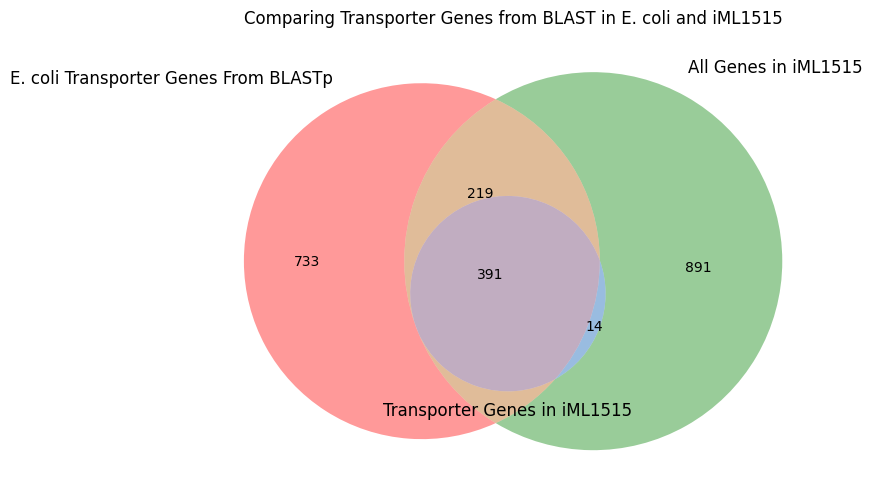

In [20]:
set1 = set(e_coli_uids)
set2 = set(all_uids_model)
set3 = set(model_transport_uids)
plt.figure(figsize=(8, 6))
venn3([set1, set2, set3],
      set_labels=("E. coli Transporter Genes From BLASTp", "All Genes in iML1515", "Transporter Genes in iML1515"))
plt.title("Comparing Transporter Genes from BLAST in E. coli and iML1515")
plt.show()

Here are the common transport genes between the BLAST and the iML1515-classified transporters

In [85]:
common_genes = set1 & set3
print(f"Genes common to BLASTp results and iML1515 transporter genes (n={len(common_genes)}):")
common_genes

Genes common to BLASTp results and iML1515 transporter genes (n=391):


{'P00550',
 'P02916',
 'P02920',
 'P02921',
 'P02924',
 'P02925',
 'P02929',
 'P02930',
 'P02931',
 'P02932',
 'P02943',
 'P03819',
 'P03959',
 'P03960',
 'P03961',
 'P04816',
 'P04983',
 'P05706',
 'P05825',
 'P06129',
 'P06609',
 'P06611',
 'P06971',
 'P06972',
 'P06996',
 'P07109',
 'P07117',
 'P07654',
 'P07821',
 'P07822',
 'P08194',
 'P08722',
 'P08839',
 'P09323',
 'P09551',
 'P09833',
 'P0A6J3',
 'P0A712',
 'P0A742',
 'P0A769',
 'P0A830',
 'P0A8H3',
 'P0A910',
 'P0A927',
 'P0A9S7',
 'P0A9X1',
 'P0AA04',
 'P0AA47',
 'P0AA67',
 'P0AA76',
 'P0AA78',
 'P0AA80',
 'P0AA82',
 'P0AAD2',
 'P0AAD4',
 'P0AAD6',
 'P0AAD8',
 'P0AAE0',
 'P0AAE2',
 'P0AAE5',
 'P0AAE8',
 'P0AAF1',
 'P0AAF3',
 'P0AAF6',
 'P0AAG0',
 'P0AAG3',
 'P0AAG8',
 'P0AAH0',
 'P0AAH4',
 'P0AAI1',
 'P0AAJ1',
 'P0AAT4',
 'P0AB93',
 'P0ABB8',
 'P0ABC9',
 'P0ABD1',
 'P0ABI4',
 'P0ABL8',
 'P0ABM1',
 'P0ABM5',
 'P0ABN5',
 'P0ABN9',
 'P0ABP3',
 'P0ABT8',
 'P0ABU7',
 'P0ABV2',
 'P0AC23',
 'P0AC26',
 'P0AC94',
 'P0AC96',
 'P0AC98',

Now, I want to look into the different reactions. This is done by comparing the set of substrates used in the reaction. It lacks precision, as iML1515 provides several CHEBIs for the same metabolite. As a temporary solution for this master, all the CHEBIs from the BLAST is here converted to a BiGG id (BID). Several CHEBIs map to the same BID. And the metabolite IDs in the model all map to one BID each. So this is a nice go-around, without using CHEBIs.\
First obtaining the ones from the BLAST.

In [ ]:
c2b_df = pd.read_csv("../../ChEBI/chebi2bigg.tsv", sep="\t")
c2b = {row["CHEBI"].upper().replace("CHEBI:", "CHEBI:"): row["BIGG"] for _, row in c2b_df.iterrows()}

temp_set_chebi = set()

for reaction_list in e_coli["Reaction"]:
    reaction_chebis = set()
    reaction_list = ast.literal_eval(reaction_list)

    for _, chebi_str in reaction_list:
        if chebi_str != "no_reaction_identified":
            matches = re.findall(r'CHEBI:\d+', chebi_str)
            reaction_chebis.update(matches)

    if reaction_chebis:
        temp_set_chebi.add(frozenset(reaction_chebis))

reactions_chebi_e_coli = [sorted(list(s)) for s in temp_set_chebi]

temp_set_bigg = set()

for chebi_set in reactions_chebi_e_coli:
    bigg_ids = {c2b.get(chebi.upper()) for chebi in chebi_set}
    bigg_ids.discard(None)  # Remove any CHEBI IDs that had no BiGG match
    
    if bigg_ids:
        temp_set_bigg.add(frozenset(bigg_ids))

reactions_bigg_e_coli = [sorted(list(s)) for s in temp_set_bigg]
reactions_bigg_e_coli


[['adp', 'atp', 'cysi__L', 'dann', 'h', 'h2o', 'pi'],
 ['fe2', 'fe3', 'h', 'h2o', 'no2', 'no3'],
 ['cu2', 'h'],
 ['galt', 'galt1p'],
 ['glu__L',
  'ile__L',
  'lys__L',
  'met__L',
  'phe__L',
  'thr__L',
  'trp__L',
  'tyr__L',
  'val__L'],
 ['cd2', 'cobalt2', 'cu2', 'fe2', 'mn2', 'zn2'],
 ['h2'],
 ['adp', 'atp', 'chol', 'gly', 'glyb', 'h', 'h2o', 'pi'],
 ['6dg', 'h', 'lcts', 'malt', 'sucr'],
 ['h', 'nad', 'nadh', 'nadp', 'nadph', 'trdox'],
 ['uacgam', 'ump', 'unaga'],
 ['adp', 'atp', 'diala__L', 'pi'],
 ['adp', 'atp', 'h', 'h2o', 'pi', 'rib__D'],
 ['h', 'k', 'na1'],
 ['adp', 'atp', 'h', 'h2o', 'na1', 'pi'],
 ['mththf'],
 ['dtdp4d6dg', 'dtdpglu', 'h2o'],
 ['btn'],
 ['cys__L', 'h', 'ttrcyc'],
 ['enter', 'h'],
 ['acnam', 'h'],
 ['adp', 'atp', 'pi', 'ttrcyc'],
 ['galctn__D', 'h'],
 ['cd2', 'fe2', 'h', 'zn2'],
 ['cm', 'h'],
 ['adp', 'atp', 'mn2', 'pi'],
 ['15dap', 'h', 'lys__L'],
 ['h', 'ile__L', 'met__L', 'val__L'],
 ['glyclt', 'h', 'lac__D', 'lac__L'],
 ['acgam', 'acgam6p'],
 ['adp', 'a

Then the substrates from the transport reactions in the model. The complete reactions from the whole model, and not just the transport reactions, would also be handy to compare, but this might be a too computationally comprehensive task, as the permutations of different CHEBIs for the same substrate, often are many, and obtaining all the permutations is both unsatisfactory and highly unefficient computationally.\
So here is the more usable BIDs, that are user-friendly, cross-reference-wise.

In [ ]:
reactions_bigg_model_init = model["Substrates (BiGG)"]
parsed_sets = [ast.literal_eval(s) for s in reactions_bigg_model_init if pd.notnull(s)]
unique_model_sets = set(frozenset(s) for s in parsed_sets)
reactions_bigg_model = [sorted(list(s)) for s in unique_model_sets]
reactions_bigg_model

[['psuri'],
 ['csn', 'h'],
 ['adp', 'atp', 'h', 'h2o', 'pa141', 'pi'],
 ['val__L'],
 ['adp', 'atp', 'h', 'h2o', 'pi', 'sulfac'],
 ['adp', 'atp', 'fe3dhbzs3', 'h', 'h2o', 'pi'],
 ['adn', 'h'],
 ['cu', 'h'],
 ['glyc3p'],
 ['btn'],
 ['sel'],
 ['acnam', 'h'],
 ['cys__L'],
 ['galctn__D', 'h'],
 ['cys__D'],
 ['cm'],
 ['pydam'],
 ['fe3dhbzs', 'h'],
 ['galctn__L', 'h'],
 ['h', 'psclys'],
 ['asn__L'],
 ['adp', 'atp', 'cbl1', 'h', 'h2o', 'pi'],
 ['h', 'spmd'],
 ['2agpg181'],
 ['dca'],
 ['ppt'],
 ['4abut', 'glu__L'],
 ['2agpe181'],
 ['man6pglyc', 'manglyc', 'pep', 'pyr'],
 ['adp', 'atp', 'feenter', 'h', 'h2o', 'pi'],
 ['h', 'pppn'],
 ['ala_B'],
 ['butso3'],
 ['nh4'],
 ['gal_bD'],
 ['amp'],
 ['5mtr'],
 ['mnl'],
 ['23cgmp'],
 ['h', 'pro__L'],
 ['h', 'ura'],
 ['2agpg141'],
 ['for', 'h'],
 ['ethso3'],
 ['adp', 'atp', 'h', 'h2o', 'maltttr', 'pi'],
 ['adp', 'atp', 'h', 'h2o', 'kdo2lipid4', 'pi'],
 ['adp', 'atp', 'cd2', 'h', 'h2o', 'pi'],
 ['ttdcea'],
 ['LalaDglu', 'h'],
 ['pydxn'],
 ['galct__D'],
 ['h'

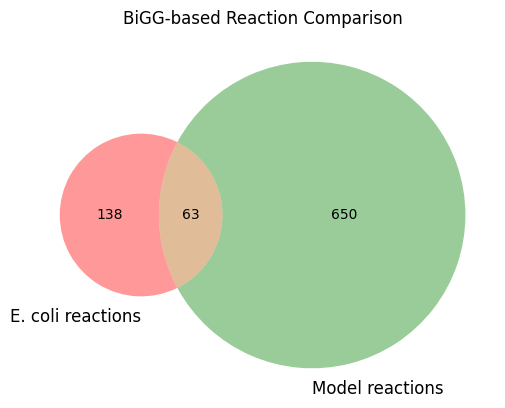

In [ ]:
set_e_coli_bigg = set(frozenset(r) for r in reactions_bigg_e_coli)
set_model_bigg = set(frozenset(r) for r in reactions_bigg_model)

plt.figure(figsize=(6, 6))
venn2([set_e_coli_bigg, set_model_bigg], set_labels=("E. coli reactions", "Model reactions"))
plt.title("BiGG-based Reaction Comparison")
plt.show()